# Try WGF on MgkPro with New Measurements.

## Prepare Notebook.

In [1]:
%reload_ext autoreload
%autoreload 2

### Import Libraries.

In [2]:
import os
import sys

import hydra
import matplotlib.pyplot as plt
import numpy as np
import omegaconf
import scanpy as sc
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import torch

import scopt
import sc_exp_design


### Import Additional Modules.

In [3]:
sys.path.insert(0, "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/shared_utils")
from experiment_utils import (
    get_forward_model,
    generate_with_condition,
    get_transformed_data,
    get_loss_fn,
    get_target_dict,
)
from inverse_utils import (
    map_df,
    loss_fn_factory,
)

### Read Configurations.

In [4]:
with hydra.initialize(
    config_path="../../loss_guidance/config"
):
    config = hydra.compose(
        config_name="run_inverse_constrained",
        overrides=[
            "paths=bloodplus_fm",
            "sampling.query_pure_cell_types=True",
            "sampling.mask_gradients=False",
            # "sampling.target_cell_type=GMP-Neutro",
            # "sampling.target_cell_type=CyclingPro1",
            # "sampling.target_cell_type=HSCs",
            # "sampling.target_cell_type=CD14Mono",
            # "sampling.target_cell_type=EryPro",
            "sampling.target_cell_type=late_MgkPro",
            # "sampling.N=10",
            # "loss_guidance.num_forward_pass_per_sample=1000",
            # "paths.perturbation_prediction_path=/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/neat-river-1_FlowMatching.pkl",
            "paths.perturbation_prediction_path=/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/wild-moon-1_FlowMatching.pkl",
            "forward_model.num_time_steps=20",
        ]
    )

/tmp/ipykernel_3417451/3081825319.py:1: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with hydra.initialize(


## Prepare Loss Function.

### Load Forward Model.

In [5]:
forward_model, (
    _,
    target_prediction_model
) = get_forward_model(config)
forward_model.target_prediction_model.resc_model["model"].eval()
forward_model.forward_model.velocity_field.eval()
print(forward_model.target_prediction_model.resc_model["model"])
print(forward_model.forward_model.velocity_field)

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Dropout(p=0.1, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=256, out_features=32, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=32, out_features=24, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


### Prepare Label Encoder for Cell Types.

In [6]:
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()


### Prepare Loss Function.

In [7]:
loss_fns = get_loss_fn(config)

target = get_target_dict(
    config,
    classes,
    forward_model.forward_model.device
)

# non_linearity = torch.nn.Identity()
non_linearity = torch.nn.ReLU()

compute_loss, noise = loss_fn_factory(
    loss_fns,
    config,
    target,
    non_linearity,
    forward_model,
)

### Load Prior Models.

In [8]:
# define paths to model checkpoints
prior_cfm_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-03-24_13-24-10/divine-grass-17_FlowMatchingWithScore.pkl"
prior_fm_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-03-24_16-31-51/swept-morning-20_FlowMap.pkl"

# initialize prior models
prior_cfm = sc_exp_design.models.FlowMatchingWithScore.load(prior_cfm_path)
prior_fm = sc_exp_design.models.FlowMap.load(prior_fm_path)
prior_cfm.velocity_field.eval()
prior_fm.flow_map.eval()

# show modules
print(prior_cfm.velocity_field)
print(prior_fm.flow_map)

NeuralVelocityFieldWithScore(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=16, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=256, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (resnet_blocks): ModuleList(
      (0-2): 3 x ResnetBlock(
        (net1): Sequential(
          (0): SiLU()
          (1): Linear(in_features=16, out_features=16, bias=True)
        )
        (cond_proj): Sequential(
          (0): SiLU()
          (1): Linear(in_features=8, out_fe

### Patch silu module.

In [9]:
# 1. Define the AD-safe SiLU
class SafeSiLU(torch.nn.Module):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x * torch.sigmoid(x)

# 2. Define the recursive patch function
def replace_silu_with_safe_silu(model: torch.nn.Module) -> None:
    for name, module in model.named_children():
        if isinstance(module, torch.nn.SiLU):
            setattr(model, name, SafeSiLU())
        else:
            # Recursively apply to sub-modules
            replace_silu_with_safe_silu(module)

# 3. Apply the patch to your specific models
velocity_field_net = prior_cfm.velocity_field
flow_map_net = prior_fm.flow_map

replace_silu_with_safe_silu(velocity_field_net)
replace_silu_with_safe_silu(flow_map_net)

print("Successfully replaced all SiLU activations with SafeSiLU.")

Successfully replaced all SiLU activations with SafeSiLU.


## LGF.

### Sample From Posterior.

In [10]:
# prepare time rescaling and posterior sampler
lgf = scopt.methods.LossGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
)

# optimization params
num_opt_samples = 100
num_time_steps = 100
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

# sample
lgf_sampling_traj = lgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
lgf_opt_samples = lgf_sampling_traj[-1]
torch.cuda.empty_cache()

## WGF.

In [11]:
# set sampler parameters
estimator = "hutch-rademacher"
gamma = 1.0
horizon = 1.0

# prepare time rescaling and posterior sampler
# time_warping = scopt.schedulers.CosineWarping(horizon=horizon)
time_warping = scopt.schedulers.LinearWarping()

wgf = scopt.methods.ULAGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
    scheduler=time_warping,
    gamma=gamma,
    estimator=estimator,
    use_flow_map_score_estimator=False,
)

#  optimization params
num_opt_samples = 100
num_time_steps = 500
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

wgf_sampling_traj = wgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
wgf_opt_samples = wgf_sampling_traj[-1]
torch.cuda.empty_cache()

## WGF with alternative score.

In [12]:
# set sampler parameters
estimator = "hutch-rademacher"
gamma = 1.0
horizon = 1.0

# prepare time rescaling and posterior sampler
# time_warping = scopt.schedulers.CosineWarping(horizon=horizon)
time_warping = scopt.schedulers.LinearWarping()

swgf = scopt.methods.ULAGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
    scheduler=time_warping,
    gamma=gamma,
    estimator=estimator,
    use_flow_map_score_estimator=True,
)

#  optimization params
num_opt_samples = 100
num_time_steps = 500
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

swgf_sampling_traj = wgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
swgf_opt_samples = swgf_sampling_traj[-1]
torch.cuda.empty_cache()

## Langevin.

In [13]:
# set sampler parameters
estimator = "hutch-rademacher"
gamma = 1.0
horizon = 1.0

# prepare time rescaling and posterior sampler
# time_warping = scopt.schedulers.CosineWarping(horizon=horizon)
time_warping = scopt.schedulers.LinearWarping()

lwgf = scopt.methods.ULAGuidedFlow(
    compute_loss,
    prior_cfm,
    flow_map=prior_fm,
    scheduler=time_warping,
    gamma=gamma,
    estimator=estimator,
    use_flow_map_score_estimator=False,
    use_langevin=True,
)

# optimization params
num_opt_samples = 100
num_time_steps = 100
solver_kwargs = {
    "method": "euler",
    "atol": 1e-5,
    "rtol": 1e-5,
}

lwgf_sampling_traj = lwgf.sample(
    num_opt_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
).detach().cpu().numpy()
lwgf_opt_samples = lwgf_sampling_traj[-1]
torch.cuda.empty_cache()

## Visualize Samples.

Text(0.5, 1.02, 'S-WGF')

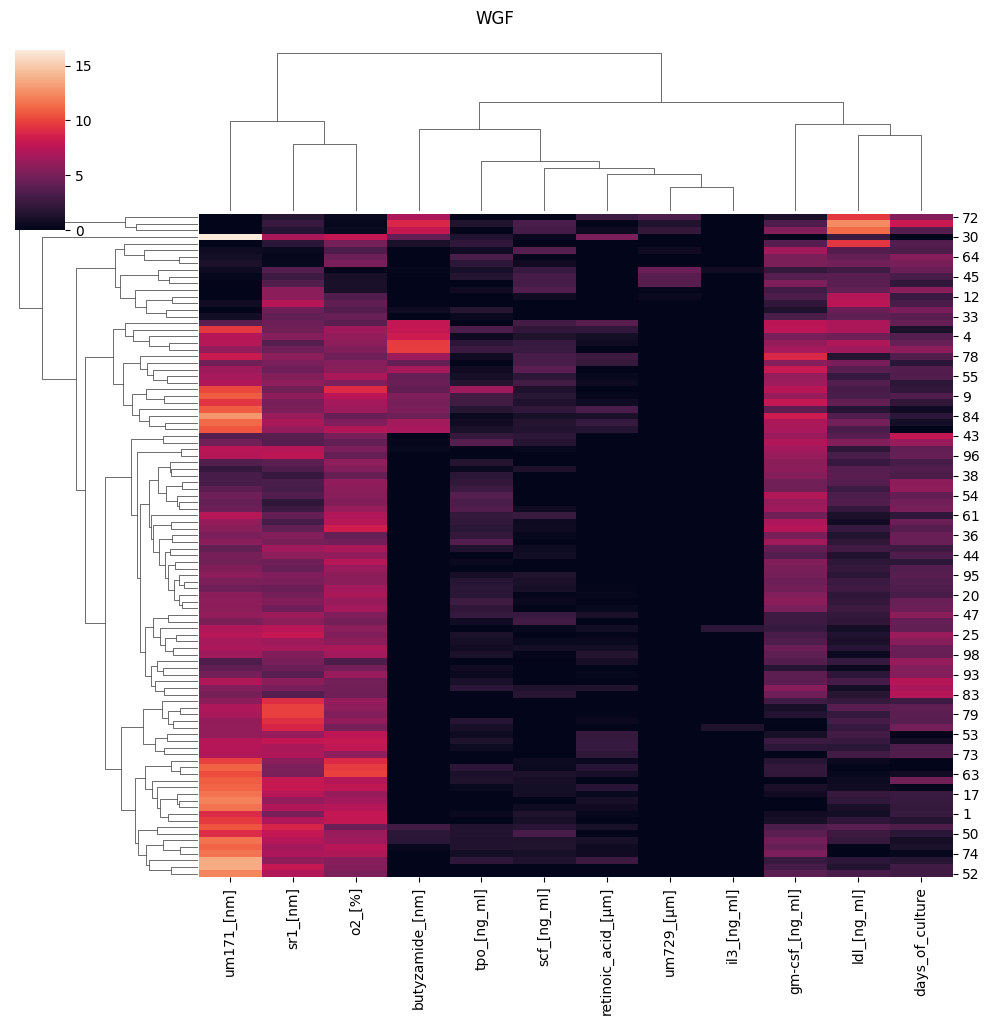

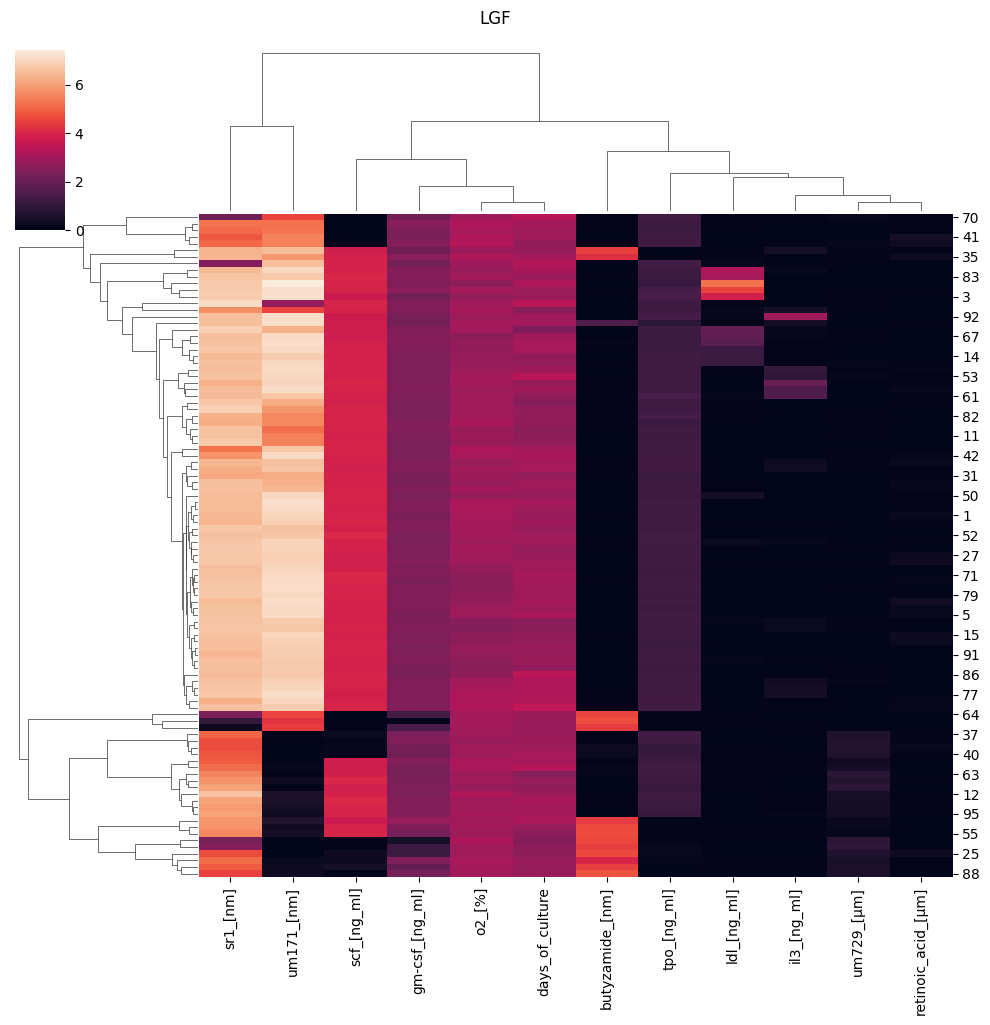

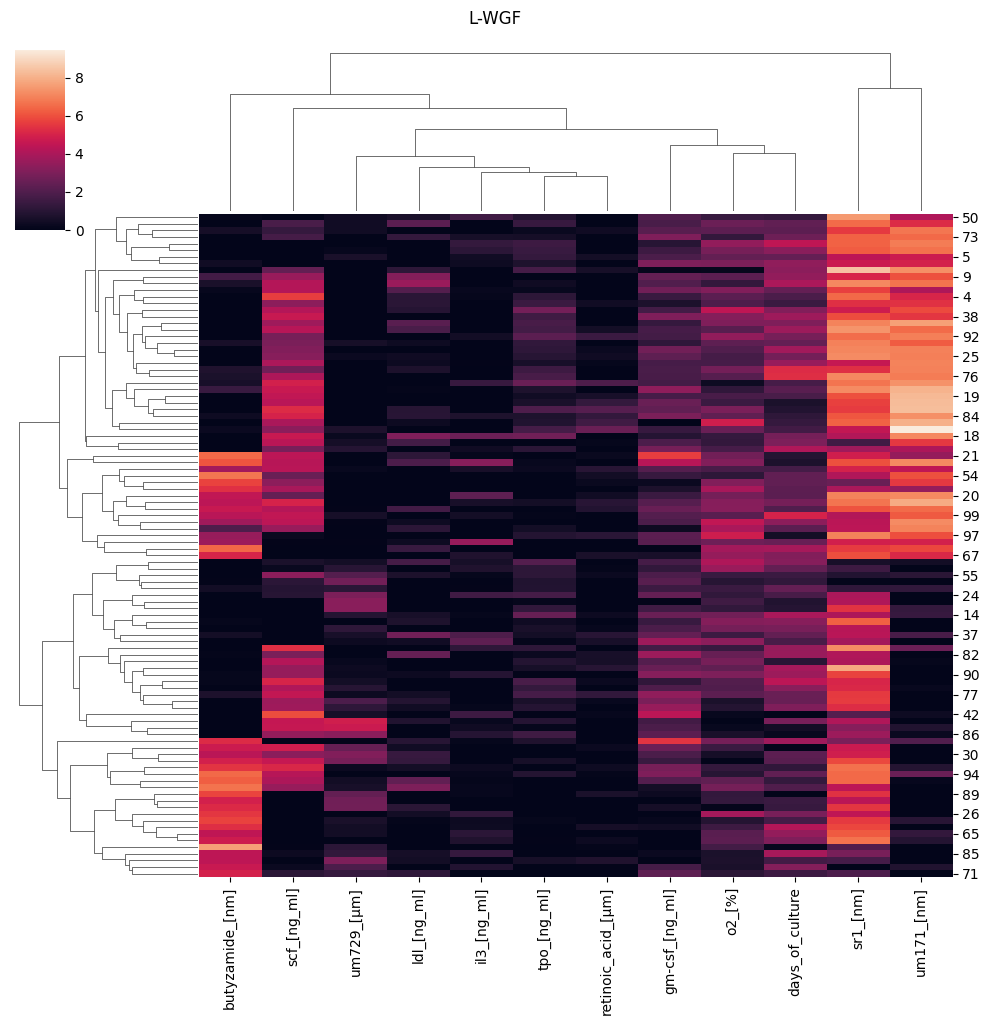

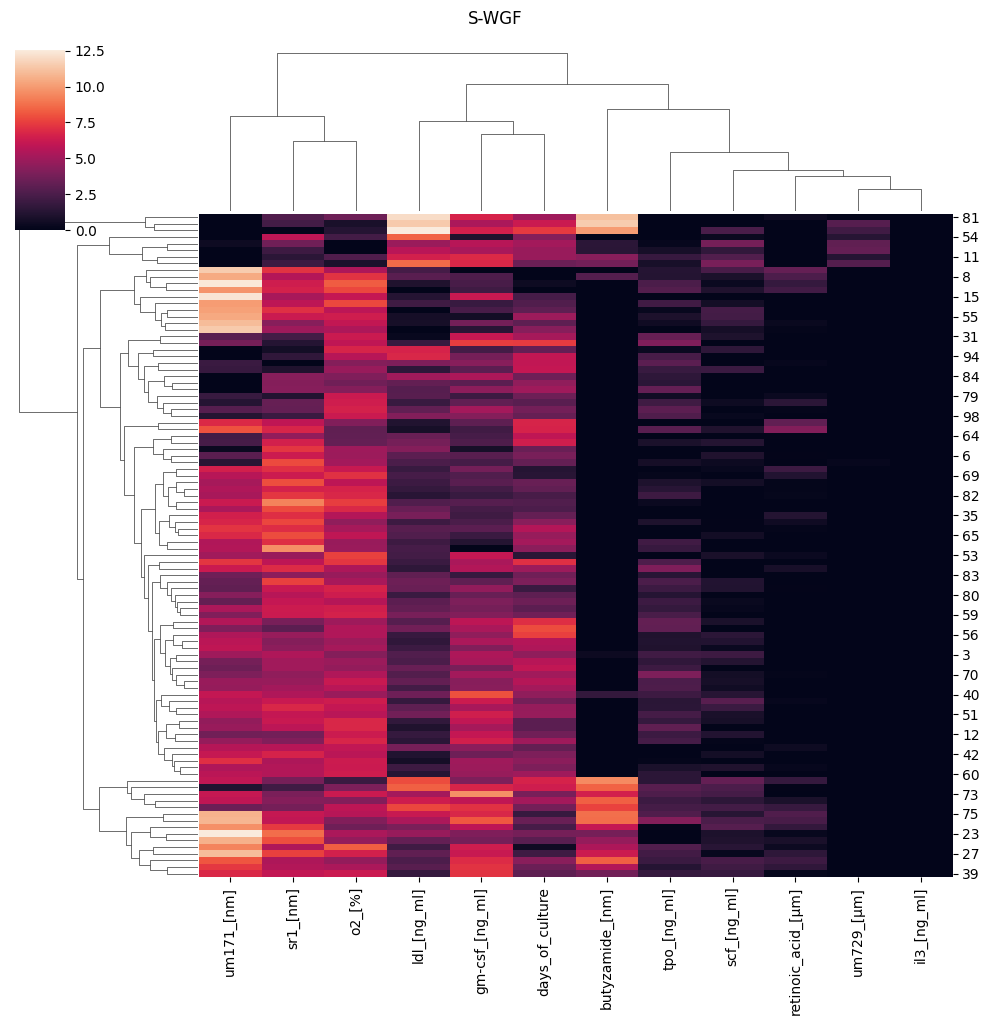

In [14]:
# WGF
g_wgf = sns.clustermap(np.maximum(wgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
g_wgf.fig.suptitle("WGF", y=1.02)  # y > 1 pushes the title slightly above the dendrogram

# LGF
g_lgf = sns.clustermap(np.maximum(lgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
g_lgf.fig.suptitle("LGF", y=1.02)

# L-WGF
g_lwgf = sns.clustermap(np.maximum(lwgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
g_lwgf.fig.suptitle("L-WGF", y=1.02)

# L-WGF
s_lwgf = sns.clustermap(np.maximum(swgf_opt_samples, 0.0), xticklabels=config.annotation.protocol_columns)
s_lwgf.fig.suptitle("S-WGF", y=1.02)


<Axes: title={'center': 'S-WGF Loss Guidance'}>

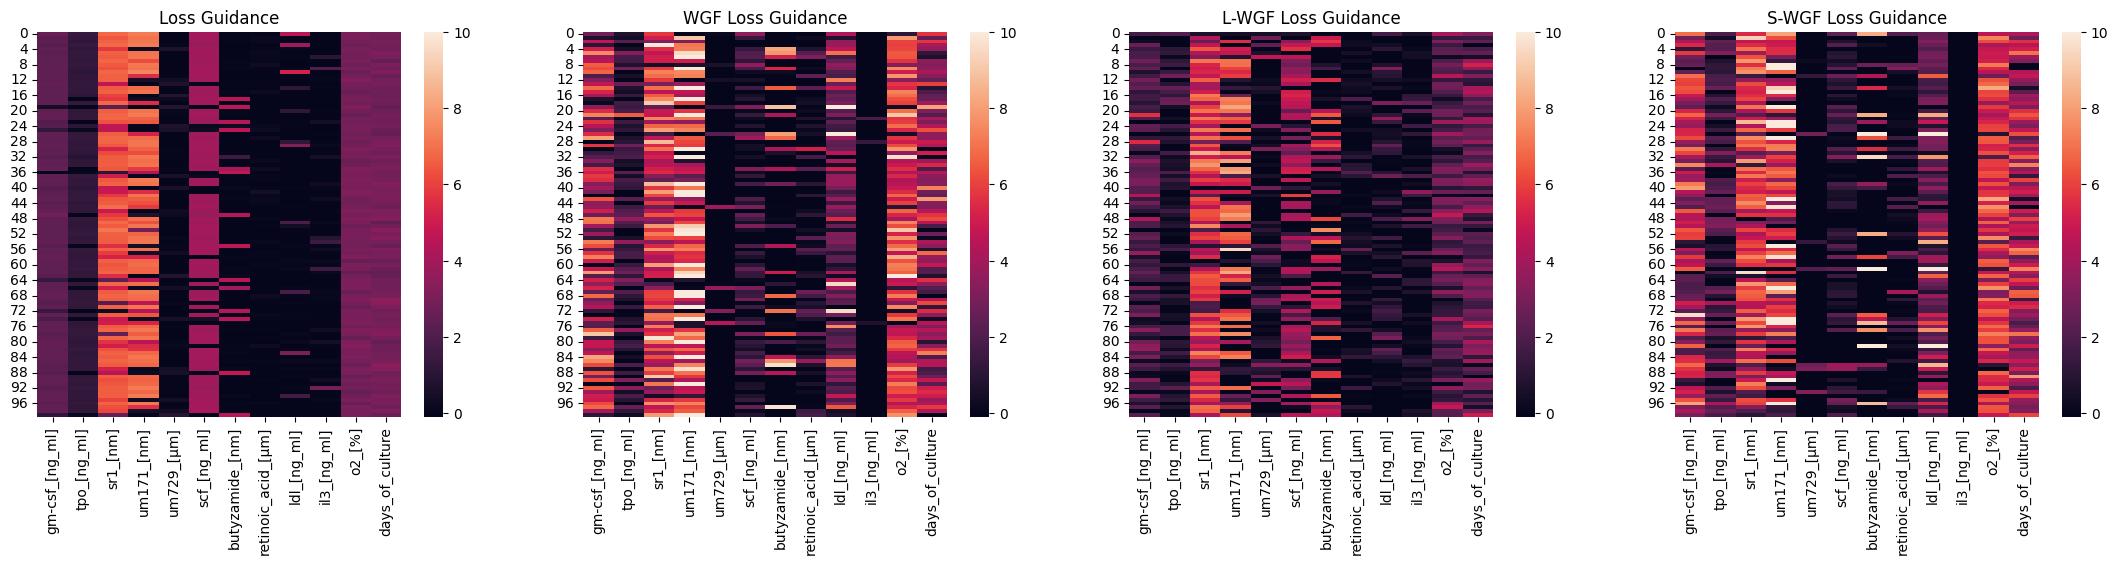

In [15]:
fig, ax = plt.subplots(1, 4, figsize=(27, 5))
vmax=0.0
vmin=10.0
ax[0].set_title("Loss Guidance")
sns.heatmap(np.maximum(lgf_opt_samples, 0.0), ax=ax[0], xticklabels=config.annotation.protocol_columns, vmin=vmin, vmax=vmax)

ax[1].set_title("WGF Loss Guidance")
sns.heatmap(np.maximum(wgf_opt_samples, 0.0), ax=ax[1], xticklabels=config.annotation.protocol_columns, vmin=vmin, vmax=vmax)

ax[2].set_title("L-WGF Loss Guidance")
sns.heatmap(np.maximum(lwgf_opt_samples, 0.0), ax=ax[2], xticklabels=config.annotation.protocol_columns, vmin=vmin, vmax=vmax)

ax[3].set_title("S-WGF Loss Guidance")
sns.heatmap(np.maximum(swgf_opt_samples, 0.0), ax=ax[3], xticklabels=config.annotation.protocol_columns, vmin=vmin, vmax=vmax)

## Compute Loss.

In [16]:
# lwgf_loss = compute_loss(torch.from_numpy(lwgf_sampling_traj[-1]).to(torch.float).to(prior_cfm.device))
# wgf_loss = compute_loss(torch.from_numpy(wgf_sampling_traj[-1]).to(torch.float).to(prior_cfm.device))
# lgf_loss = compute_loss(torch.from_numpy(lgf_sampling_traj[-1]).to(torch.float).to(prior_cfm.device))

## plot Loss.

In [17]:
# sns.histplot(lwgf_loss.detach().cpu(), stat="density", color="green", label="l-wgf")
# sns.kdeplot(lwgf_loss.detach().cpu(), color="green")

# sns.histplot(wgf_loss.detach().cpu(), stat="density", color="blue", label="wgf")
# sns.kdeplot(wgf_loss.detach().cpu(), color="blue")

# sns.histplot(lgf_loss.detach().cpu(), stat="density", color="red", label="lgf")
# sns.kdeplot(lgf_loss.detach().cpu(), color="red")

# plt.legend()


## Query Forward Model.

In [18]:
num_sample_fwd = 350

print("wgf")
wgf_gen = generate_with_condition(
    wgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)

print("l-wgf")
lwgf_gen = generate_with_condition(
    lwgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)

print("s-wgf")
swgf_gen = generate_with_condition(
    swgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)
print("lgf")
lgf_gen = generate_with_condition(
    lgf_opt_samples,
    forward_model,
    num_time_steps,
    solver_kwargs,
    ct_le,
    num_samples=num_sample_fwd,
    # noise=noise,
    logger=None,
    n_scatter_feats=6,
)


wgf
l-wgf
s-wgf
lgf


In [19]:
tgt_idx = ct_le.classes_.tolist().index("EryPro")
wgf_max = wgf_gen["ct_probs"].mean(0)[:, tgt_idx].max(0)
lgf_max = lgf_gen["ct_probs"].mean(0)[:, tgt_idx].max(0)
lwgf_max = lwgf_gen["ct_probs"].mean(0)[:, tgt_idx].max(0)
swgf_max = swgf_gen["ct_probs"].mean(0)[:, tgt_idx].max(0)
print(f"{wgf_max=}, {lgf_max=}, {lwgf_max=}, {swgf_max=}")

wgf_max=np.float32(0.14358999), lgf_max=np.float32(0.16486438), lwgf_max=np.float32(0.39964598), swgf_max=np.float32(0.25941437)


Text(0.5, 1.02, 'S-WGF')

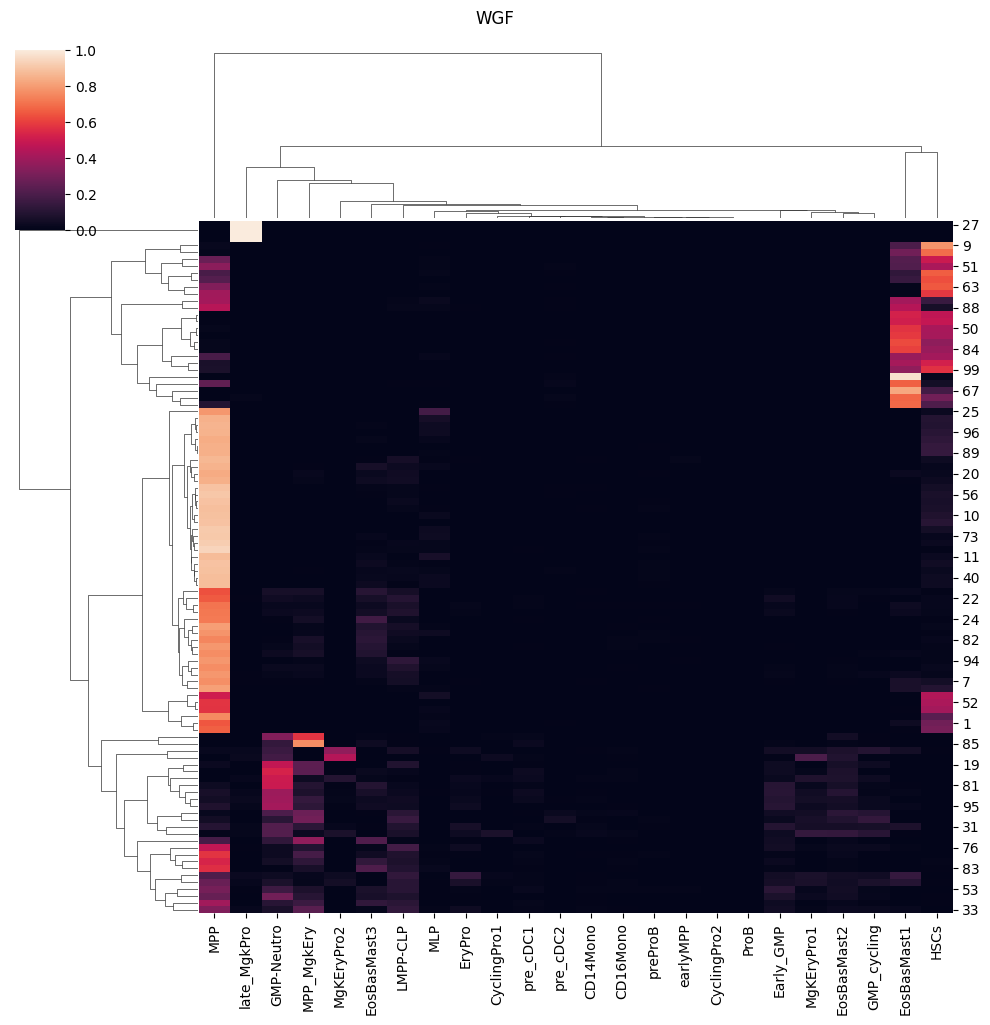

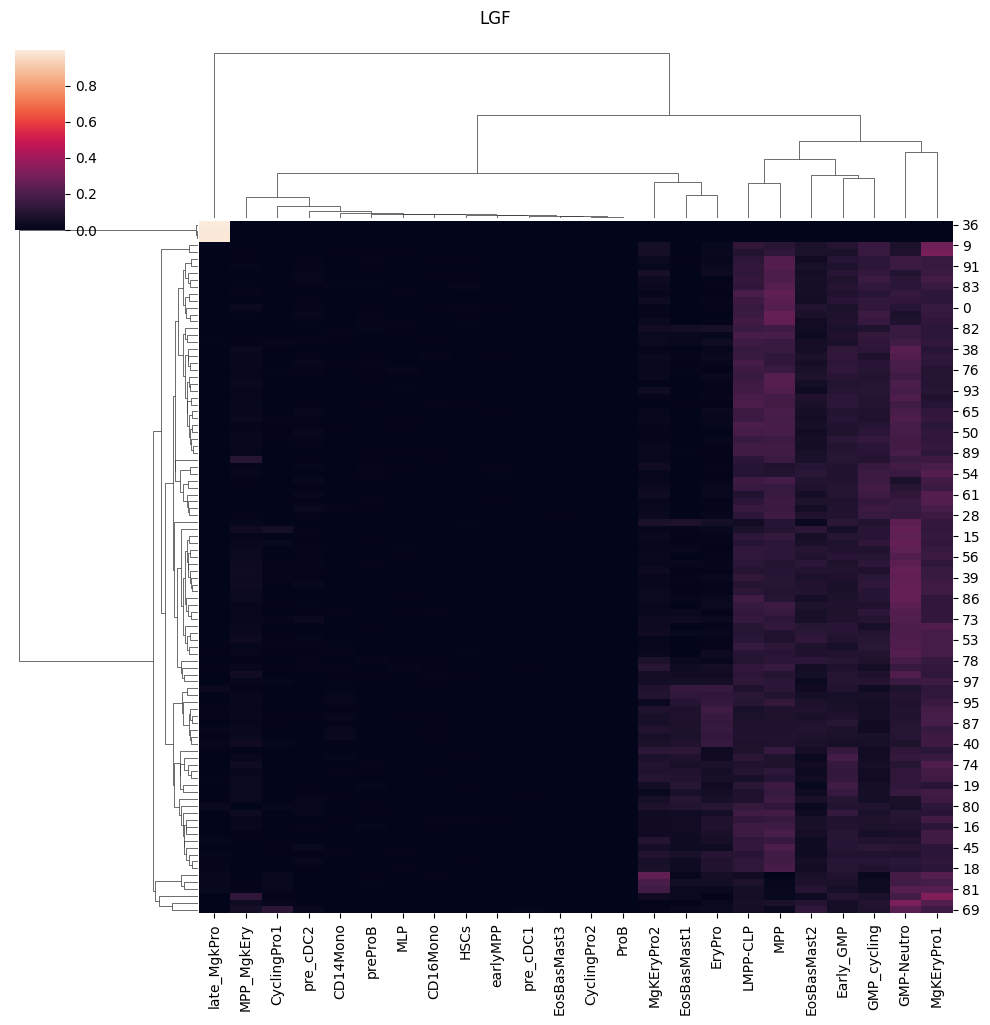

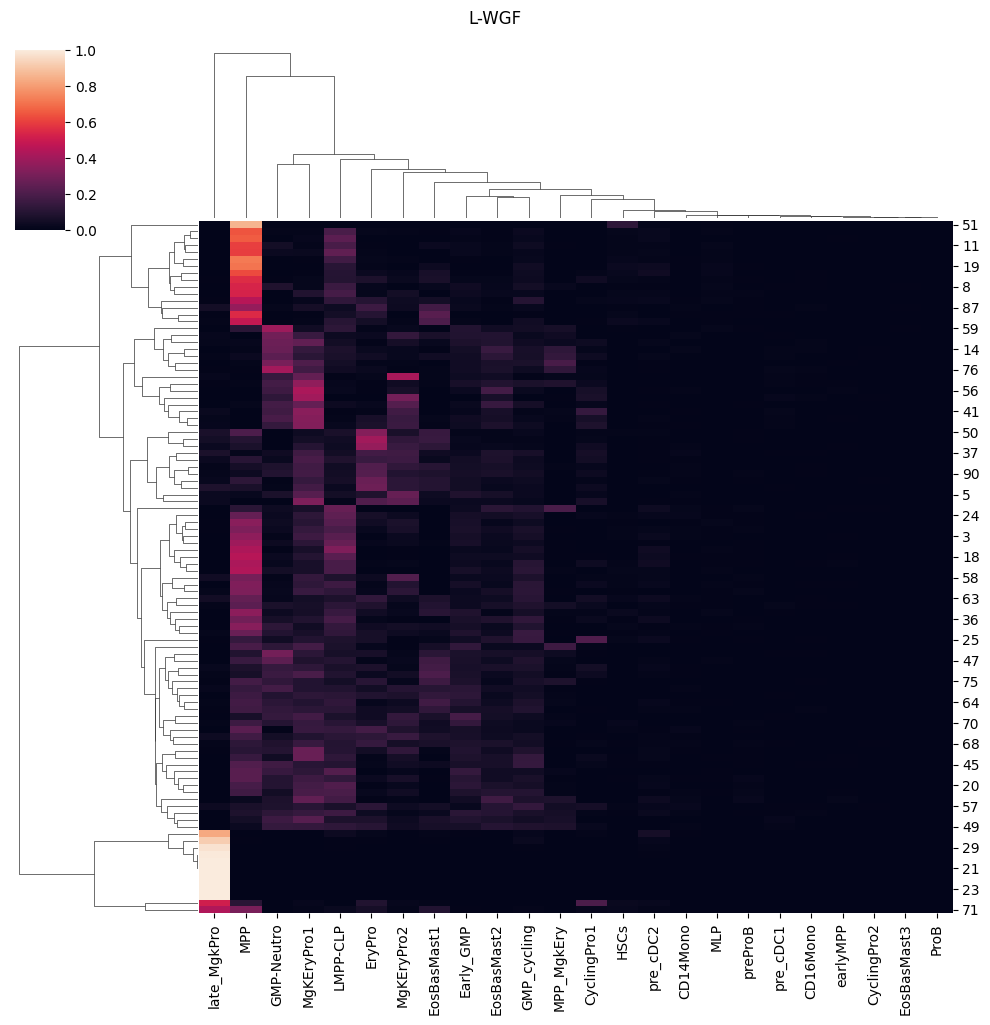

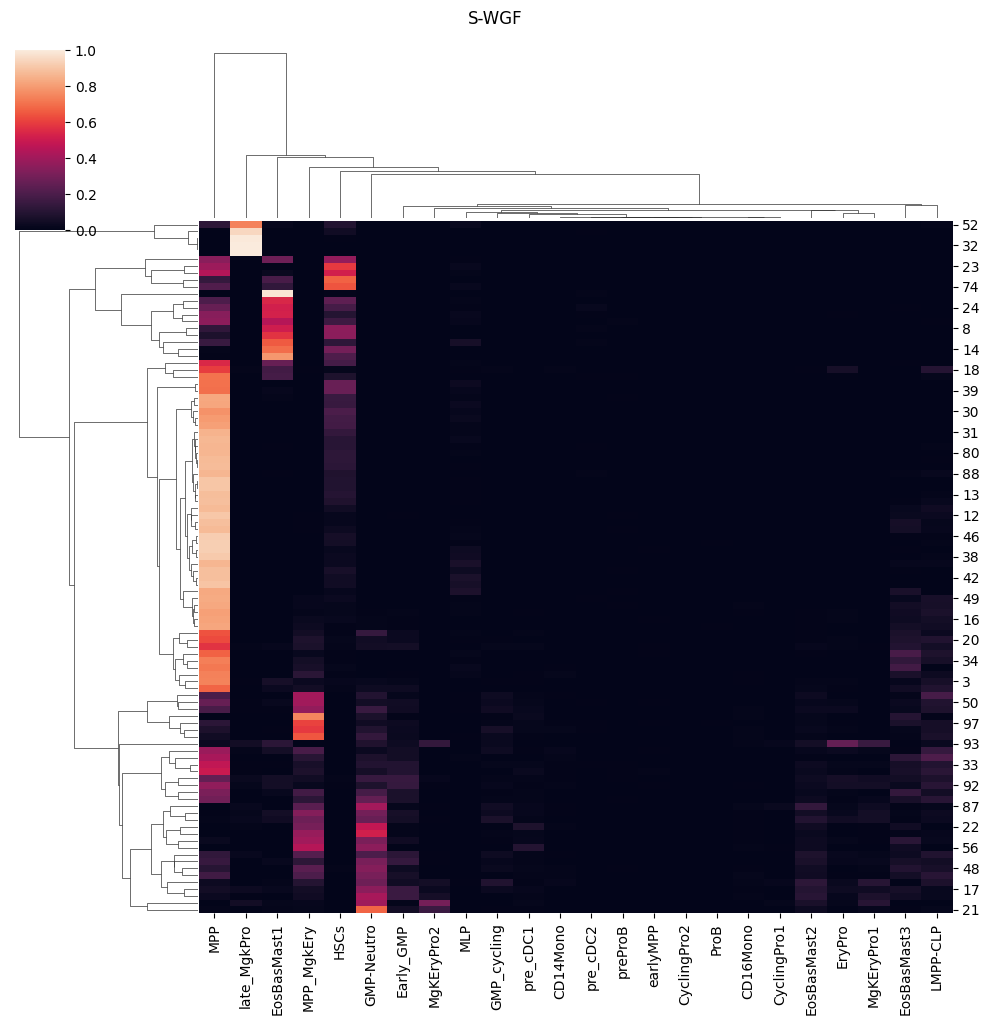

In [20]:
# WGF
g_wgf = sns.clustermap(wgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
g_wgf.fig.suptitle("WGF", y=1.02)  # y > 1 pushes the title slightly above the dendrogram

# LGF
g_lgf = sns.clustermap(lgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
g_lgf.fig.suptitle("LGF", y=1.02)

# L-WGF
g_lwgf = sns.clustermap(lwgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
g_lwgf.fig.suptitle("L-WGF", y=1.02)

# L-WGF
s_lwgf = sns.clustermap(swgf_gen["ct_probs"].mean(0), xticklabels=ct_le.classes_)
s_lwgf.fig.suptitle("S-WGF", y=1.02)


<Axes: title={'center': 'S-WGF Loss Guidance'}>

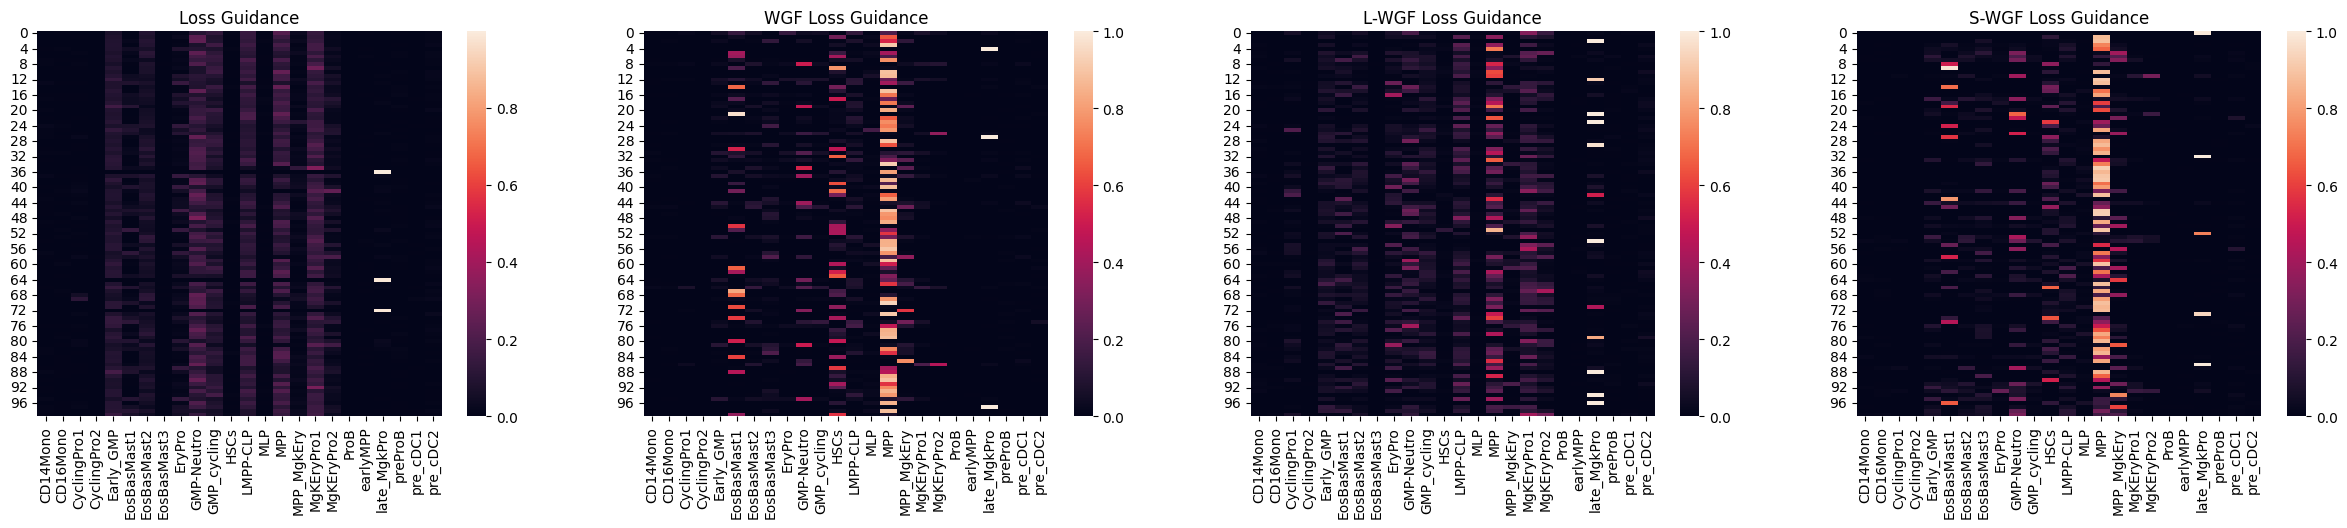

In [21]:
fig, ax = plt.subplots(1, 4, figsize=(30, 5))

ax[0].set_title("Loss Guidance")
sns.heatmap(lgf_gen["ct_probs"].mean(0), ax=ax[0], xticklabels=ct_le.classes_)

ax[1].set_title("WGF Loss Guidance")
sns.heatmap(wgf_gen["ct_probs"].mean(0), ax=ax[1], xticklabels=ct_le.classes_)

ax[2].set_title("L-WGF Loss Guidance")
sns.heatmap(lwgf_gen["ct_probs"].mean(0), ax=ax[2], xticklabels=ct_le.classes_)

ax[3].set_title("S-WGF Loss Guidance")
sns.heatmap(swgf_gen["ct_probs"].mean(0), ax=ax[3], xticklabels=ct_le.classes_)

### Transform and Filter.

In [22]:
import pandas as pd

from data_utils import get_protocol_tranformations
from inverse_utils import map_df

protocol_tranf = get_protocol_tranformations(
    config.annotation.protocol_columns,
    log1p_exp_cols=config.annotation.log1p_exp_cols,
    log21p_exp_cols=config.annotation.log21p_exp_cols,
    inverse=True
)

opt_samples = {
    "wgf": wgf_opt_samples,
    "lgf": lgf_opt_samples,
    "swgf": swgf_opt_samples,
    "lwgf": lwgf_opt_samples,
}
opt_dfs = {}

for key, samples in opt_samples.items():
    df = pd.DataFrame(
        {k: samples[idx] for idx, k in enumerate(config.annotation.protocol_columns)}
    )
    df = map_df(df, protocol_tranf)
    opt_dfs[key] = df


In [25]:
for method, df in opt_dfs.items():
    margin = .5
    # hsc_df = pure_cell_type_solution_dict_concat[target_ct][protocol_cols].copy()  # Use .copy() to avoid warnings
    hsc_df = df.copy()  # Use .copy() to avoid warnings
    # Initial filtering
    o2_mask = (hsc_df["o2_[%]"] > 5.) & (hsc_df["o2_[%]"] < 25.)
    days_mask = (hsc_df["days_of_culture"] > 12.) & (hsc_df["days_of_culture"] < 20.)
    m = (o2_mask & days_mask)
    m_previous = m

    hsc_df["pass"] = m
    hsc_df["filtering_step"] = "pass"
    hsc_df.loc[~m, "filtering_step"] = "oxy_days"  # FIXED: proper indexing

    # Apply parameter bounds
    for param in config.annotation.protocol_columns:
        if param in bounds:  # Only process if bounds are defined
            idx_bounds = np.logical_and(
                hsc_df[param] >= bounds[param][0] - margin*bounds[param][0], 
                hsc_df[param] <= bounds[param][1] + margin*bounds[param][1]
            )
            m = idx_bounds & m
            hsc_df["pass"] = m
            # Update filtering_step for newly excluded rows
            hsc_df.loc[~idx_bounds & m_previous, "filtering_step"] = param  # Need to track previous m
            m_previous = m

    # Better approach - track filtering step for each failure reason
    hsc_df["pass"] = True
    hsc_df["filtering_step"] = "pass"

    # Check oxygen
    o2_mask = (hsc_df["o2_[%]"] > 5.) & (hsc_df["o2_[%]"] < 25.)
    hsc_df.loc[~o2_mask, "pass"] = False
    hsc_df.loc[~o2_mask, "filtering_step"] = "o2"

    # Check days
    days_mask = (hsc_df["days_of_culture"] > 12.) & (hsc_df["days_of_culture"] < 20.)
    hsc_df.loc[~days_mask, "pass"] = False
    hsc_df.loc[~days_mask, "filtering_step"] = "days"

    # Check other parameters
    for param in protocol_cols:
        if param not in ['o2_[%]', 'days_of_culture'] and param in bounds:
            param_mask = (hsc_df[param] >= bounds[param][0]) & (hsc_df[param] <= bounds[param][1])
            hsc_df.loc[~param_mask, "pass"] = False
            hsc_df.loc[~param_mask, "filtering_step"] = param

    # Plotting
    plt.figure()
    sns.barplot(x=hsc_df["filtering_step"].value_counts().index, y=hsc_df["filtering_step"].value_counts().values)
    plt.tick_params("x",rotation=90)
    plt.title("Pass/Fail Counts")

    is_pass_mask = hsc_df["pass"]
    hsc_df_all = pure_cell_type_solution_dict_concat[target_ct]
    hsc_df_pass_all_cols = hsc_df_all.loc[is_pass_mask]
    print("MAX prop passed: ", hsc_df_pass_all_cols[f"{target_ct}_prop"].max())
    print("MAX prop all: ", hsc_df_all[f"{target_ct}_prop"].max())
    plt.figure()
    sns.histplot(hsc_df_pass_all_cols[f"{target_ct}_prop"], stat="density")
    plt.title(f"{target_ct}_prop Distribution (Passing Samples)")
    print(hsc_df_pass_all_cols.shape)

NameError: name 'bounds' is not defined